In [3]:
# This is a temporary requirement. One of the files tess-asteroids retrieves on import is currently having an issue.
# I have reported the problem to TSSC/MIT, so hopefully it will be fixed soon.
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

from tess_asteroids import MovingTPF
from tess_asteroids.utils import plot_img_aperture
from tess_asteroids.utils import target_observability
import numpy as np
from astropy.timeseries import LombScargle
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import scipy
from scipy.signal import medfilt

In [4]:
def compute_absolute_mag(Tmag, r, delta, phase_deg, G=0.15):
    """
    Tmag: TESS magnitude
    r: distance from Sun, in AU
    delta: distance from observer, in AU
    phase_deg: phase angle, in degrees
    G: slope parameter. 0.15 is a common default for unknown asteroid types.
    """

    # Convert magnitude in TESS bandpass to visual magnitude (Woods+21)
    Vmag = Tmag + 0.671
    
    # Basis functions Phi1 and Phi2 (approximations from Muinonen et al. 2010)
    phase_rad = np.radians(phase_deg)
    phi1 = np.exp(-3.33 * np.tan(0.5 * phase_rad)**0.63)
    phi2 = np.exp(-1.87 * np.tan(0.5 * phase_rad)**1.22)    

    # Calculate the phase correction
    phase_func = (1 - G) * phi1 + G * phi2

    return Vmag - 5*np.log10(r*delta) + 2.5*np.log10(phase_func)

In [5]:
def mad_clip(t, y, yerr, clip=5, width=11):
    '''
    Remove outliers from time-series data.

    Data more than clip*MAD from a smoothed version of the data are
    removed, where MAD is the mean absolute deviation from the
    median-smoothed data.
    
    clip: tolerance on clipping
    width: width of window for median-smoothing filter
    '''

    # medfilt pads the array to be filtered with zeros.
    # Centre LC on zero => edge behaviour is better
    filtered = medfilt(y-np.nanmedian(y), width)+np.nanmedian(y)
    difference = abs(filtered - y)
    mad = np.nanmean(difference)
    good = difference < clip*mad

    return t[good], y[good], yerr[good], sum(~good), good

In [7]:
# target_observability(target=f"DES = 2{3703:07}")

In [159]:
target = MovingTPF.from_name(f"DES = 2{116618:07}", sector=3, camera=1, ccd=2)

# Make TPF
target.make_tpf()

Warning from TESSSpacecraft(): {message : ErfaWarning('ERFA function "dtf2d" yielded 1 of "dubious year (Note 6)"'), category : 'ErfaWarning', filename : '/Users/jimartin/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/erfa/core.py', lineno : 133, line : None}
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Column(s) >= 2093 '), category : 'LKPRFWarning', filename : '/Users/jimartin/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 56, line : None}
Warning from `prf.evaluate()`: {message : LKPRFWarning('`targets` contains collateral pixels: Column(s) >= 2093 '), category : 'LKPRFWarning', filename : '/Users/jimartin/miniforge3/envs/tess-asteroids/lib/python3.10/site-packages/lkprf/tessprf.py', lineno : 56, line : None}
  0%|                                                                               | 0/11349 [00:00<?, ?it/s]When computing the star model for pixel 0 (row 596, column 2071) 

In [160]:
name = "116618 (2004 BU116)"

In [161]:
# Make PSF photometry LC - we want this to be at 30 minute cadence.
target.make_lc(method="psf", time_bin_size = None if target.sector < 27 else 30/60/24)
lc = target.lc["psf"]

# Compute absolute magnitude
absolute_mag = compute_absolute_mag(lc["TESSmag"], lc["sun_distance"], lc["obs_distance"], lc["sto_angle"])

100%|█████████████████████████████████████████████████████████████████████| 923/923 [00:00<00:00, 5317.50it/s]


In [162]:
# Remove nans from LC - periodogram cannot have nans as input.

no_nan = np.logical_and(~np.isnan(np.array(absolute_mag)), ~np.isnan(np.array(lc["TESSmag_err"])))
time, absolute_mag, mag_err = lc["time"][no_nan], absolute_mag[no_nan], lc["TESSmag_err"][no_nan]
print("Before masking = {0}".format(len(lc["time"])))
print("After nan masking = {0}".format(len(time)))

Before masking = 923
After nan masking = 894


In [164]:
# Remove poor quality data from LC, using built-in helper function with default settings.
# This masks cadences with bad SPOC quality and bad lightcurve quality.

# good_quality = target.create_lc_quality_mask(spoc_quality = lc["spoc_quality"][no_nan], lc_quality = lc["quality"][no_nan])
good_quality = (lc["spoc_quality"][no_nan] == 0) & (lc["quality"][no_nan] == 0)
time, absolute_mag, mag_err = time[good_quality], absolute_mag[good_quality], mag_err[good_quality]
print("After bad data masking = {0}".format(len(time)))

After bad data masking = 674


In [165]:
# Iterative outlier clipping

width = 11 # width = 11 is a reasonable value for 30 minute caence data. Adjust for other cadences.
clipped = np.inf
while clipped > 0:
    time, absolute_mag, mag_err, clipped, _ = mad_clip(time, absolute_mag, mag_err, clip=5, width=width)
print("After outlier clipping = {0}".format(len(time)))

After outlier clipping = 666


In [166]:
# Min/max period, in days, and frequency
cadence = np.nanmedian(np.diff(time))
Pmin, Pmax = cadence*8, (np.nanmax(time)-np.nanmin(time))
Pmin, Pmax = cadence*8, 10
fmin, fmax = 1/Pmax, 1/Pmin

# Define period and frequency grid
frequency_grid = np.linspace(fmin, fmax, 100000)
period_grid = 1.0/frequency_grid

# Run periodogram
ls = LombScargle(time, absolute_mag, mag_err, fit_mean=True)
power = ls.power(frequency_grid)

# False alarm levels
probabilities = [0.1,0.05,0.01]
false_alarm_levels = ls.false_alarm_level(probabilities)

# Find peaks in the periodogram above 1% FAP.
level = false_alarm_levels[2]
peaks, peak_properties = find_peaks(power, height=level)
peak_periods = period_grid[peaks]
sorted_ind = np.argsort(peak_properties["peak_heights"])[::-1]
best_period1 = peak_periods[sorted_ind[0]]

In [167]:
Pmin, Pmax

(0.16667030880671518, 10)

In [168]:
# For sector 69, we want LC at native cadence just for plotting:
if target.sector >= 27:
    
    target.make_lc(method="psf")
    lc_native = target.lc["psf"]
    
    # Compute absolute magnitude
    absolute_mag_native = compute_absolute_mag(lc_native["TESSmag"], lc_native["sun_distance"], lc_native["obs_distance"], lc_native["sto_angle"])

    # Remove nans from LC
    no_nan = np.logical_and(~np.isnan(np.array(absolute_mag_native)), ~np.isnan(np.array(lc_native["TESSmag_err"])))
    time_native, absolute_mag_native, mag_err_native = lc_native["time"][no_nan], absolute_mag_native[no_nan], lc_native["TESSmag_err"][no_nan]

    # Remove poor quality data from LC, using built-in helper function with default settings.
    # This masks cadences with bad SPOC quality and bad lightcurve quality.
    good_quality = target.create_lc_quality_mask(spoc_quality = lc_native["spoc_quality"][no_nan], lc_quality = lc_native["quality"][no_nan])
    time_native, absolute_mag_native, mag_err_native = time_native[good_quality], absolute_mag_native[good_quality], mag_err_native[good_quality]

    # Iterative outlier clipping
    width = 23 # width = 23 gives reasonable result for 200sec data.
    clipped = np.inf
    while clipped > 0:
        time_native, absolute_mag_native, mag_err_native, clipped, _ = mad_clip(time_native, absolute_mag_native, mag_err_native, clip=5, width=width)
        

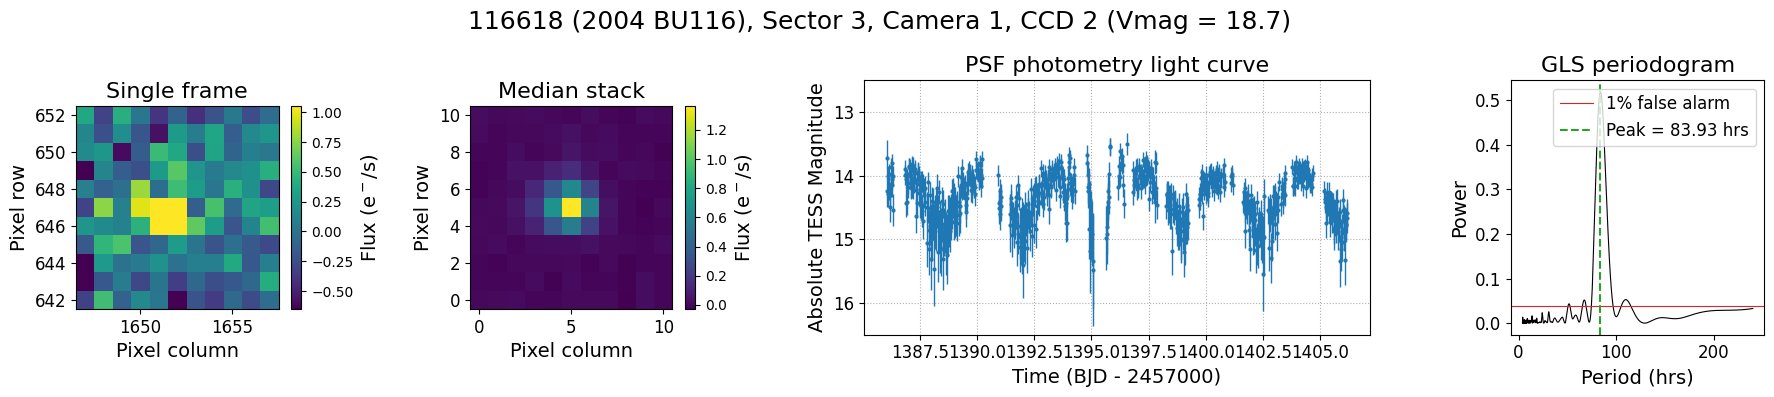

In [171]:
# Choose single frames to plot for example TPF
if target.sector < 27:
    frame=600
elif target.sector >= 56:
    frame=1089

# Plot the TPF, LCF and periodogram
fig, (ax1,ax2,ax3,ax4) = plt.subplots(1,4, figsize=(18,4), width_ratios=[1,1,2,1])

plot_img_aperture(target.corr_flux[frame], np.full(shape=(11, 11), fill_value=False), ax=ax1, corner=target.corner[frame])
ax1.set_title(f"Single frame", fontsize=16)
ax1.set_xlabel("Pixel column", fontsize=14)
ax1.set_ylabel("Pixel row", fontsize=14)
ax1.tick_params(labelsize=12)
cbar = ax1.images[-1].colorbar
cbar.set_label(r"Flux (e$^-$/s)", fontsize=14)

im = ax2.imshow(np.nanmedian(target.corr_flux, axis=0), origin="lower", aspect="equal")
ax2.set_title(f"Median stack", fontsize=16)
ax2.set_xlabel("Pixel column", fontsize=14)
ax2.set_ylabel("Pixel row", fontsize=14)
ax2.tick_params(labelsize=12)
cbar = fig.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label(r"Flux (e$^-$/s)", fontsize=14)

if target.sector < 27:
    ax3.errorbar(time, absolute_mag, yerr=mag_err, color='tab:blue', marker='o', ls="", ms=2, elinewidth=1)
else:
    ax3.plot(time_native, absolute_mag_native, color='silver', marker='o', ms=1, ls="", label = "200sec cadence")
    ax3.errorbar(time, absolute_mag, yerr=mag_err, color='tab:blue', marker='o', ls="", ms=2, elinewidth=1, label = "Binned 30min cadence")

ax3.set_xlabel("Time (BJD - 2457000)", fontsize=14)
ax3.set_ylabel("Absolute TESS Magnitude", fontsize=14)
ax3.tick_params(labelsize=12)
ax3.grid(ls=":")
ax3.invert_yaxis()
ax3.set_ylim(16.5,12.5)
ax3.set_title("PSF photometry light curve", fontsize=16)

ax4.axhline(y=level, color='tab:red', lw=0.8, label = "1% false alarm")
ax4.axvline(x=best_period1*24, ls='--', color='tab:green', zorder=2, label = "Peak = {0:.2f} hrs".format(best_period1*24))
ax4.plot(period_grid*24, power, 'k', lw=0.8, zorder=0)
ax4.set_xlabel("Period (hrs)", fontsize=14)
ax4.set_ylabel("Power", fontsize=14)
ax4.tick_params(labelsize=12)
ax4.legend(fontsize=12, loc="upper right")
ax4.set_title("GLS periodogram", fontsize=16)
# ax4.set_xlim(0,50)

fig.suptitle("{0}, Sector {1}, Camera {2}, CCD {3} (Vmag = {4:.01f})".format(name, target.sector,target.camera,target.ccd,target.lc_hdulist[0].header["VMAG"]), fontsize=18)

fig.tight_layout()
plt.savefig("./figures/c2_proposal/tess-{}_{}-{}-{}_image_lightcurve_periodogram.png".format(target.target.split(" ")[-1],target.sector,target.camera,target.ccd), dpi=200, bbox_inches="tight")
plt.show()
plt.close(fig)

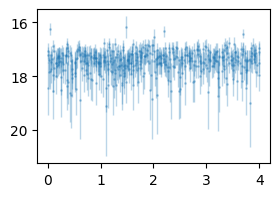

In [141]:
t0 = time[len(time)//2]
phase = (time % best_period1*2) / best_period1*2
plt.figure(figsize=(3,2))
plt.errorbar(phase, absolute_mag, yerr=mag_err, color='tab:blue', marker='o', ls="", ms=1, elinewidth=1, alpha=0.3)
plt.gca().invert_yaxis()
# plt.scatter(phase, absolute_mag, color='tab:blue', marker='o', s=2)

In [118]:
time.max() - time.min()

20.228836487299304